In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [24]:
train_path = "/Users/JulioJerez/Desktop/Docs. Personales/Repositorio/PROYECTOS/store-sales-forecasting/data/raw/store-sales-time-series-forecasting/train.csv"
train = pd.read_csv(train_path, parse_dates=['date'])

In [25]:
train['year']=train['date'].dt.year
train['month']=train['date'].dt.month
train['day']=train['date'].dt.day
train['dow']=train['date'].dt.dayofweek ## 0=monday ... 6=sunday

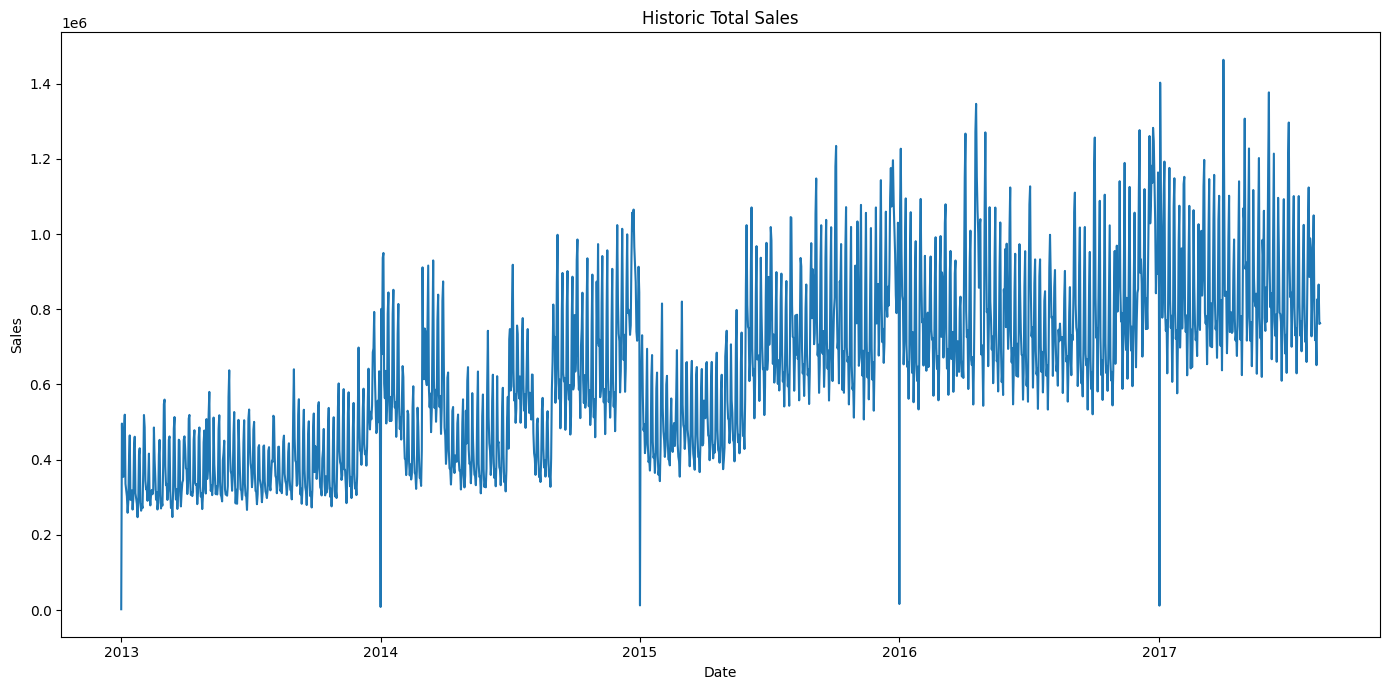

In [26]:
daily_sales = train.groupby("date")["sales"].sum()

plt.figure(figsize=(14,7))
plt.plot(daily_sales)
plt.title("Historic Total Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

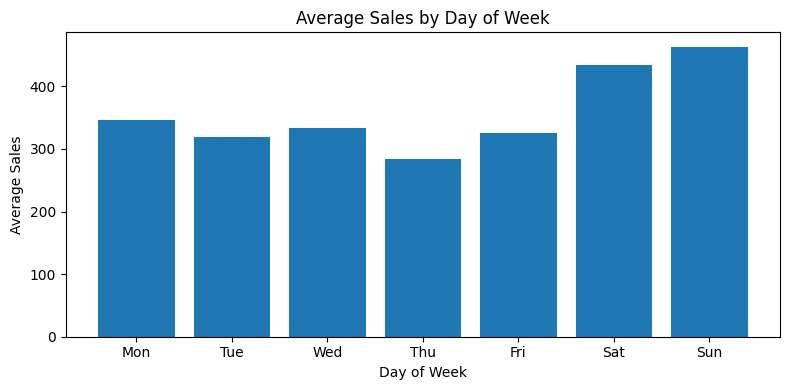

In [27]:
# 0=monday ... 6=sunday
dow_avg = train.groupby("dow")["sales"].mean()

dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

plt.figure(figsize=(8,4))
plt.bar(dow_labels, dow_avg.values)
plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()

#### Weekend (Sat/Sun) shows the highest average sales → strong weekly seasonality.
#### This supports using dayofweek as a feature and lag_7 in modeling.


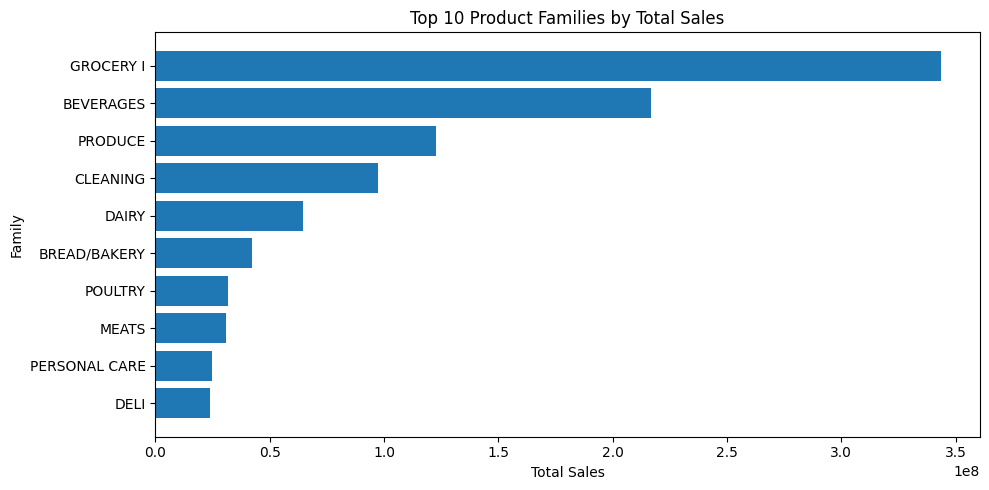

In [28]:
top10_families = (
    train.groupby("family")["sales"].sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
plt.barh(top10_families.index[::-1], top10_families.values[::-1])
plt.title("Top 10 Product Families by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Family")
plt.tight_layout()
plt.show()

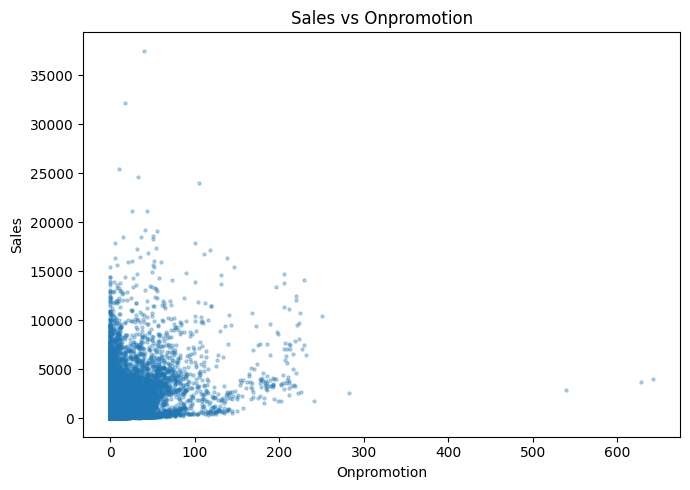

In [29]:
sample = train.sample(100_000, random_state=42)

plt.figure(figsize=(7,5))
plt.scatter(sample["onpromotion"], sample["sales"], s=5, alpha=0.3)
plt.title("Sales vs Onpromotion")
plt.xlabel("Onpromotion")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

/var/folders/kf/wqvl62316tgf28k5cfmtvj_h0000gn/T/ipykernel_7739/2701379908.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([sales_no_promo, sales_promo], labels=["No promo", "Promo"])


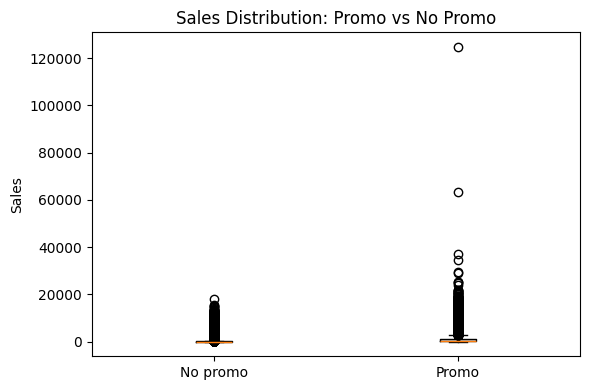

In [30]:
promo_flag = (train["onpromotion"] > 0)
sales_no_promo = train.loc[~promo_flag, "sales"].sample(100_000, random_state=42)
sales_promo    = train.loc[promo_flag,  "sales"].sample(100_000, random_state=42)

plt.figure(figsize=(6,4))
plt.boxplot([sales_no_promo, sales_promo], labels=["No promo", "Promo"])
plt.title("Sales Distribution: Promo vs No Promo")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

b0 (intercept): 2459434.7413955596
b1 (slope): 16407.590438782725


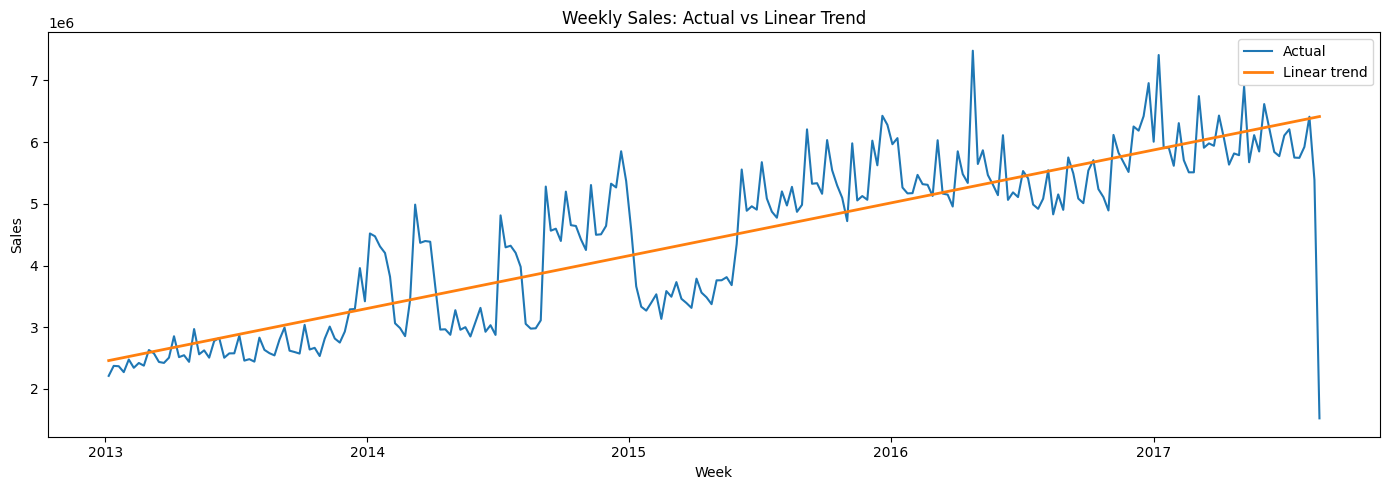

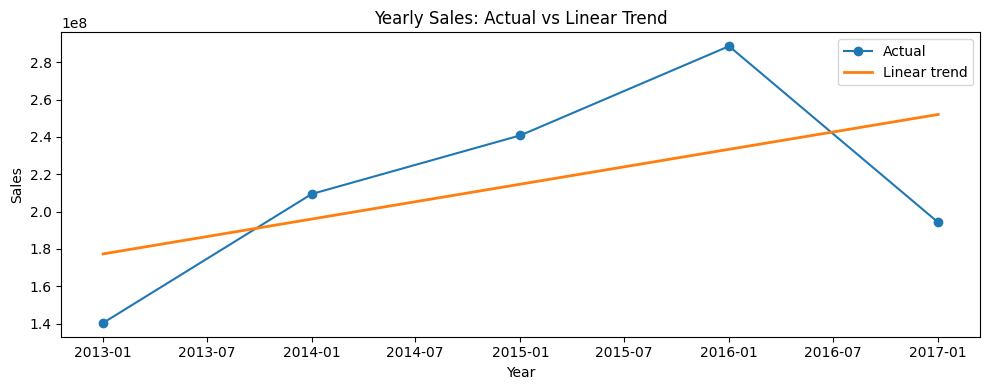

In [31]:
# daily total sales
daily = train.groupby("date")["sales"].sum().sort_index().to_frame("sales")
#daily.head()

weekly = daily.resample("W")["sales"].sum().to_frame("sales")
weekly["t"] = np.arange(len(weekly))

X = weekly[["t"]]
y = weekly["sales"]

lr = LinearRegression().fit(X, y)
weekly["trend"] = lr.predict(X)

print("b0 (intercept):", lr.intercept_)
print("b1 (slope):", lr.coef_[0])

plt.figure(figsize=(14,5))
plt.plot(weekly.index, weekly["sales"], label="Actual")
plt.plot(weekly.index, weekly["trend"], linewidth=2, label="Linear trend")
plt.title("Weekly Sales: Actual vs Linear Trend")
plt.xlabel("Week")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

yearly = daily.resample("YS")["sales"].sum().to_frame("sales")  # inicio de año
yearly["t"] = np.arange(len(yearly))

X = yearly[["t"]]
y = yearly["sales"]

lr_y = LinearRegression().fit(X, y)
yearly["trend"] = lr_y.predict(X)

plt.figure(figsize=(10,4))
plt.plot(yearly.index, yearly["sales"], marker="o", label="Actual")
plt.plot(yearly.index, yearly["trend"], linewidth=2, label="Linear trend")
plt.title("Yearly Sales: Actual vs Linear Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()